In [2]:
import json
import yfinance as yf
import logging
import datetime
from utils import ComputandoMetricas, verificando_valores_nulos, retorno_percentual_acao_individual, retorno_carteira_monetario, get_selic_multiplos_periodos,compute_metrics
from IPython.display import display, Markdown
import pandas as pd
from matplotlib import pyplot as plt
import os
plt.figure(figsize=(10, 6))

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

with open("../../data/pesos_carteira_historico.json", "r") as f:
    results_dict = json.load(f)

results_dict = dict(sorted(results_dict.items(), key=lambda x: x[0].split('_to_')[0]))  
 
valor_investido = 1000   

save_path = "../../data/"

c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
01/22/2026 10:22:08 AM USER_AGENT environment variable not set, consider setting it to identify your requests.


<Figure size 1000x600 with 0 Axes>

In [3]:
if '2018-01-01_to_2020-10-01' in results_dict:
    del results_dict['2018-01-01_to_2020-10-01']
if '2018-04-01_to_2020-01-01' in results_dict:
    del results_dict['2018-04-01_to_2020-01-01']

In [ ]:
logger.info("Gerando pesos marcowitz...")

pesos_carteira_marcowitz = {}

for key, value in results_dict.items(): 
    
    acoes = list(value['tickers_weights'].keys())
    
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    
    data_split = key.split("_to_")
    
    start = data_split[0]
    
    end = data_split[1]
    
    try:
    
        comp = ComputandoMetricas(str(start), str(end), value['tickers_weights'],1000)
            
        weights_markowitz, _ = comp.computando_marcowitz()
            
        computando_marcowitz = weights_markowitz.iloc[-1].to_dict()
            
        pesos_carteira_marcowitz[f"{start}_to_{end}"] = computando_marcowitz
    except Exception as e:
        logger.error(f"Erro ao computar Markowitz para o período {start} a {end}: {e}")
        continue
    
    
logger.info("Coletando dados das ações da carteira e do markowitz para o proximo periodo")

In [5]:
pesos_carteira_marcowitz = dict(sorted(pesos_carteira_marcowitz.items(), key=lambda x: x[0].split('_to_')[0]))

In [ ]:
"""precos_carteira = {}

end_anterior = "2015-01-01"

for key, value in results_dict.items():
    
    acoes = list(value['tickers_weights'].keys())
    
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    
    data_split = key.split("_to_")

    start = data_split[1]
    
    data = pd.Timestamp(start)
    
    end = data + pd.DateOffset(months=3)
    
    end = end.strftime("%Y-%m-%d")
    
    date_now = datetime.datetime.now().strftime("%Y-%m-%d")
    
    if end > date_now:
        logger.info("Data final da carteira maior que a data atual, ajustando para a data atual.")
        end = date_now

    logger.info(f"Baixando dados da carteira de {start} a {end}, para as acoes {acoes_sa}")
    
    precos_carteira[f"{start}"] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]
    
    #pesos = list(value['tickers_weights'].values())
    
    end_anterior = end"""
    
    

In [ ]:
precos_carteira = {}

end_anterior = "2015-01-01"

acoes_anterior = []

for key, value in results_dict.items():

    data_split = key.split("_to_")

    start = data_split[1]
   
    dt_ini = pd.Timestamp(end_anterior)
    
    dt_fim = pd.Timestamp(start)

    diff_meses = (dt_fim.year - dt_ini.year) * 12 + (dt_fim.month - dt_ini.month)

    if diff_meses > 3 or (diff_meses == 3 and dt_fim.day >= dt_ini.day):
    
        acoes_sa_new = acoes_anterior
        
        start_new = end_anterior    
    
        end_new = start
        
        date_now_new = datetime.datetime.now().strftime("%Y-%m-%d")
        
        if end_new > date_now_new:
            logger.info("Data final da carteira maior que a data atual, ajustando para a data atual.")
            end_new = date_now_new
        
        logger.info(f"Trimestre comecado em {start_new} e finalizado em {end_new} nao possui dados, usando dados da carteira de {start_new} a {end_anterior}, para as acoes {acoes_sa_new}")
    
        precos_carteira[f"{start_new}"] = yf.download(acoes_sa_new, start=str(start_new), end= str(end_new))["Close"]
          
    acoes = list(value['tickers_weights'].keys())
    
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    
    data = pd.Timestamp(start)
        
    end = data + pd.DateOffset(months=3)
        
    end = end.strftime("%Y-%m-%d")
        
    date_now = datetime.datetime.now().strftime("%Y-%m-%d")
        
    if end > date_now:
        logger.info("Data final da carteira maior que a data atual, ajustando para a data atual.")
        end = date_now

    logger.info(f"Baixando dados da carteira de {start} a {end}, para as acoes {acoes_sa}")
    
    precos_carteira[f"{start}"] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]
        
    end_anterior = end
    
    acoes_anterior = acoes_sa

In [70]:
precos_carteira = dict(sorted(precos_carteira.items(), key=lambda x: x[0]))

In [71]:
precos_carteira

{'2015-01-01': Ticker      TAEE3.SA  WEGE3.SA   YDUQ3.SA
 Date                                     
 2015-01-02   3.79193  4.729569  14.761744
 2015-01-05   3.79193  4.761816  13.878048
 2015-01-06   3.79193  4.691181  13.067992
 2015-01-07   3.79193  4.637436  12.659616
 2015-01-08   3.79193  4.715750  13.054605
 ...              ...       ...        ...
 2015-03-25   3.79193  4.799291  12.117350
 2015-03-26   3.79193  4.712510  12.077183
 2015-03-27   3.79193  4.802390  12.057098
 2015-03-30   3.79193  4.934112  12.699786
 2015-03-31   3.79193  4.927912  12.405220
 
 [61 rows x 3 columns],
 '2015-04-01': Ticker       AZZA3.SA  CGRA4.SA   MULT3.SA  RADL3.SA  TAEE4.SA  WEGE3.SA
 Date                                                                    
 2015-04-01  17.071278  5.966511  13.893306  4.787968       NaN  5.011594
 2015-04-02  17.408573  5.927258  13.937969  5.069221       NaN  5.008495
 2015-04-06  17.725214  5.895856  14.392068  5.089310       NaN  5.020894
 2015-04-07  17.8

In [ ]:
"""precos_carteira_marcowitz = {}

for key, value in pesos_carteira_marcowitz.items():
    
    acoes = list(value.keys())
    
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    
    data_split = key.split("_to_")

    start = data_split[1]
    
    data = pd.Timestamp(start)
    
    end = data + pd.DateOffset(months=3)
    
    end = end.strftime("%Y-%m-%d")
    
    date_now = datetime.datetime.now().strftime("%Y-%m-%d")
    
    if end > date_now:
        logger.info("Data final da carteira maior que a data atual, ajustando para a data atual.")
        end = date_now
        
    logger.info(f"Baixando dados de marcowitz {start} a {end}, para as acoes {acoes_sa}")
    
    precos_carteira_marcowitz[f'{start}'] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]"""
    
    
    

In [ ]:
precos_carteira_marcowitz = {}

end_anterior = "2015-01-01"

acoes_anterior = []

for key, value in pesos_carteira_marcowitz.items():
    
    data_split = key.split("_to_")

    start = data_split[1]
    
    dt_ini = pd.Timestamp(end_anterior)
    
    dt_fim = pd.Timestamp(start)

    diff_meses = (dt_fim.year - dt_ini.year) * 12 + (dt_fim.month - dt_ini.month)

    if diff_meses > 3 or (diff_meses == 3 and dt_fim.day >= dt_ini.day):
    
        acoes_sa_new = acoes_anterior
        
        start_new = end_anterior    
    
        end_new = start
        
        date_now_new = datetime.datetime.now().strftime("%Y-%m-%d")
        
        if end_new > date_now_new:
            logger.info("Data final da carteira maior que a data atual, ajustando para a data atual.")
            end_new = date_now_new
        
        logger.info(f"Trimestre comecado em {start_new} e finalizado em {end_new} nao possui dados, usando dados da carteira de {start_new} a {end_anterior}, para as acoes {acoes_sa_new}")
    
        precos_carteira_marcowitz[f"{start_new}"] = yf.download(acoes_sa_new, start=str(start_new), end= str(end_new))["Close"]
    
    acoes = list(value.keys())
    
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    
    data = pd.Timestamp(start)
    
    end = data + pd.DateOffset(months=3)
    
    end = end.strftime("%Y-%m-%d")
    
    date_now = datetime.datetime.now().strftime("%Y-%m-%d")
    
    if end > date_now:
        logger.info("Data final da carteira maior que a data atual, ajustando para a data atual.")
        end = date_now
        
    logger.info(f"Baixando dados de marcowitz {start} a {end}, para as acoes {acoes_sa}")
    
    precos_carteira_marcowitz[f'{start}'] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]

    end_anterior = end
    
    acoes_anterior = acoes_sa

In [ ]:

end_anterior = "2015-01-01"

for key, value in results_dict.items():
    
    data_split = key.split("_to_")
    
    start = data_split[0]
    
    end = data_split[1]
    
    dt_ini = pd.Timestamp(end_anterior)
    
    dt_fim = pd.Timestamp(end)
    
    print(f"dt_ini: {dt_ini}, dt_fim: {dt_fim}")

    diff_meses = (dt_fim.year - dt_ini.year) * 12 + (dt_fim.month - dt_ini.month)
    
    #print(f"dt_ini: {dt_ini}, dt_fim: {dt_fim}, diff_meses: {diff_meses}, dt_fim.day: {dt_fim.day}, dt_ini.day: {dt_ini.day}")

    if diff_meses > 6 or (diff_meses == 6 and dt_fim.day >= dt_ini.day):
        
        data = pd.Timestamp(end_anterior)
    
        end = data + pd.DateOffset(months=3)
    
        end = end.strftime("%Y-%m-%d")
        
        print(end)
        
        print(precos_carteira[end])
    
    end = data_split[1]
    
    print(end)
    
    end_anterior = end
    

In [ ]:
carteira = pd.DataFrame()
carteira_marcowitz = pd.DataFrame()

interacoes = 0

for key, value in results_dict.items():
    
    data_split = key.split("_to_")
    
    start = data_split[0]
    
    end = data_split[1]
    
    print("*" * 40)
    
    display(Markdown(f"**O retorno da carteira para o período: {key}**"))
    
    pesos_carteira = value['tickers_weights']
    
    precos_carteira_selecionada = precos_carteira[end]
    
    pesos_sem_erro = verificando_valores_nulos(pesos_carteira, precos_carteira_selecionada)
    
    precos_sem_nan = precos_carteira[end].dropna(axis=1)
    
    carteira_percentual_acoes = retorno_percentual_acao_individual(pesos_sem_erro, precos_sem_nan)
    
    try:
        pesos_carteira_marcowitz_selecionada = pesos_carteira_marcowitz[key]
        precos_carteira_marcowitz_selecionada = precos_carteira_marcowitz[end]
        pesos_sem_erro_markowitz = verificando_valores_nulos(pesos_carteira_marcowitz_selecionada, precos_carteira_marcowitz_selecionada)
        pesos_sem_erro_markowitz = {key_: value*100 for key_, value in pesos_sem_erro_markowitz.items()}
    
        precos_sem_nan_markwitz = precos_carteira_marcowitz[end].dropna(axis=1)
    
        carteira_percentual_acoes_marcowitz = retorno_percentual_acao_individual(pesos_sem_erro_markowitz, precos_sem_nan_markwitz)
    except Exception as e:  
        logger.info(f"Erro ao obter:{e}")
    
    data = pd.DataFrame(pesos_sem_erro, index=["Pesos"]).T
    data_markwitz = pd.DataFrame(pesos_sem_erro_markowitz, index=["Pesos"]).T
    
    if not carteira_percentual_acoes.empty:
        data['retornos em %'] = pd.DataFrame(carteira_percentual_acoes)
        data_markwitz['retornos markwitz em %'] = pd.DataFrame(carteira_percentual_acoes_marcowitz)
    else:
        print("Nenhum dado foi obtido!")
        
    display(data.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))
    
    display(data_markwitz.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))
    
    data.to_csv(f"{save_path}/historico_carteira/pesos_{key}_carteira.csv")
    
    data_markwitz.to_csv(f"{save_path}/historico_carteira_markowitz/pesos_{key}_carteira_markowitz.csv")
    
    if interacoes == 0:
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), valor_investido)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), valor_investido)
        

        
    else:   
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), valor_atual_carteira)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), valor_atual_carteira_markwitz)
        
    print(valor_carteira)
        
    #print(valor_carteira_markwitz)
    
    carteira = pd.concat([carteira, valor_carteira])
    carteira_marcowitz = pd.concat([carteira_marcowitz, valor_carteira_markwitz])
    
    try:
        valor_atual_carteira = int(valor_carteira.iloc[-1])
        valor_atual_carteira_markwitz = int(valor_carteira_markwitz.iloc[-1])
    
    except:
        pass
    
    interacoes = interacoes + 1
    
    end_anterior = end

In [ ]:
carteira = pd.DataFrame()

carteira_marcowitz = pd.DataFrame()

interacoes = 0

end_anterior = "2015-01-01"

for key, value in results_dict.items():
    
    data_split = key.split("_to_")
    
    start = data_split[0]
    
    end = data_split[1]
    
    dt_ini = pd.Timestamp(end_anterior)
    
    dt_fim = pd.Timestamp(end)
    
    diff_meses = (dt_fim.year - dt_ini.year) * 12 + (dt_fim.month - dt_ini.month)
    
    if diff_meses > 6 or (diff_meses == 6 and dt_fim.day >= dt_ini.day):
        
        data_new = pd.Timestamp(end_anterior)
    
        end_new = data_new + pd.DateOffset(months=3)
    
        end_new = end_new.strftime("%Y-%m-%d")
        
        precos_carteira_selecionada = precos_carteira[end_new]
        
        pesos_sem_erro = verificando_valores_nulos(pesos_carteira_anterior, precos_carteira_selecionada)
        
        precos_sem_nan = precos_carteira[end_new].dropna(axis=1)
        
        carteira_percentual_acoes = retorno_percentual_acao_individual(pesos_sem_erro, precos_sem_nan)
        
        try:
            
            precos_carteira_marcowitz_selecionada = precos_carteira_marcowitz[end_new]
            
            pesos_sem_erro_markowitz = verificando_valores_nulos(pesos_carteira_marcowitz_selecionada_anterior, precos_carteira_marcowitz_selecionada)
            
            pesos_sem_erro_markowitz = {key_: value*100 for key_, value in pesos_sem_erro_markowitz.items()}
        
            precos_sem_nan_markwitz = precos_carteira_marcowitz[end_new].dropna(axis=1)
        
            carteira_percentual_acoes_marcowitz = retorno_percentual_acao_individual(pesos_sem_erro_markowitz, precos_sem_nan_markwitz)
        except Exception as e:  
            logger.info(f"Erro ao obter:{e}")
        
        data = pd.DataFrame(pesos_sem_erro, index=["Pesos"]).T
        data_markwitz = pd.DataFrame(pesos_sem_erro_markowitz, index=["Pesos"]).T
        
        if not carteira_percentual_acoes.empty:
            data['retornos em %'] = pd.DataFrame(carteira_percentual_acoes)
            data_markwitz['retornos markwitz em %'] = pd.DataFrame(carteira_percentual_acoes_marcowitz)
        else:
            print("Nenhum dado foi obtido!")
        
        display(data.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))
    
        display(data_markwitz.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))
        
        data.to_csv(f"{save_path}/historico_carteira/pesos_{key}_carteira.csv")
        
        data_markwitz.to_csv(f"{save_path}/historico_carteira_markowitz/pesos_{key}_carteira_markowitz.csv")
        
        if interacoes == 0:
            valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), valor_investido)
            
            valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), valor_investido)
            

            
        else:   
            valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), valor_atual_carteira)
            
            valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), valor_atual_carteira_markwitz)
            
        print(valor_carteira)
        
    #print(valor_carteira_markwitz)
    
    carteira = pd.concat([carteira, valor_carteira])
    carteira_marcowitz = pd.concat([carteira_marcowitz, valor_carteira_markwitz])
    
    try:
        valor_atual_carteira = int(valor_carteira.iloc[-1])
        valor_atual_carteira_markwitz = int(valor_carteira_markwitz.iloc[-1])
    
    except:
        pass
        
    
    print("*" * 40)
    
    display(Markdown(f"**O retorno da carteira para o período: {key}**"))
    
    pesos_carteira = value['tickers_weights']
    
    precos_carteira_selecionada = precos_carteira[end]
    
    pesos_sem_erro = verificando_valores_nulos(pesos_carteira, precos_carteira_selecionada)
    
    precos_sem_nan = precos_carteira[end].dropna(axis=1)
    
    carteira_percentual_acoes = retorno_percentual_acao_individual(pesos_sem_erro, precos_sem_nan)
    
    try:
        pesos_carteira_marcowitz_selecionada = pesos_carteira_marcowitz[key]
        
        precos_carteira_marcowitz_selecionada = precos_carteira_marcowitz[end]
        
        pesos_sem_erro_markowitz = verificando_valores_nulos(pesos_carteira_marcowitz_selecionada, precos_carteira_marcowitz_selecionada)
        
        pesos_sem_erro_markowitz = {key_: value*100 for key_, value in pesos_sem_erro_markowitz.items()}
    
        precos_sem_nan_markwitz = precos_carteira_marcowitz[end].dropna(axis=1)
    
        carteira_percentual_acoes_marcowitz = retorno_percentual_acao_individual(pesos_sem_erro_markowitz, precos_sem_nan_markwitz)
    except Exception as e:  
        logger.info(f"Erro ao obter:{e}")
    
    data = pd.DataFrame(pesos_sem_erro, index=["Pesos"]).T
    data_markwitz = pd.DataFrame(pesos_sem_erro_markowitz, index=["Pesos"]).T
    
    if not carteira_percentual_acoes.empty:
        data['retornos em %'] = pd.DataFrame(carteira_percentual_acoes)
        data_markwitz['retornos markwitz em %'] = pd.DataFrame(carteira_percentual_acoes_marcowitz)
    else:
        print("Nenhum dado foi obtido!")
        
    display(data.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))
    
    display(data_markwitz.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))
    
    data.to_csv(f"{save_path}/historico_carteira/pesos_{key}_carteira.csv")
    
    data_markwitz.to_csv(f"{save_path}/historico_carteira_markowitz/pesos_{key}_carteira_markowitz.csv")
    
    if interacoes == 0:
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), valor_investido)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), valor_investido)
        

        
    else:   
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), valor_atual_carteira)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), valor_atual_carteira_markwitz)
        
    print(valor_carteira)
        
    #print(valor_carteira_markwitz)
    
    carteira = pd.concat([carteira, valor_carteira])
    carteira_marcowitz = pd.concat([carteira_marcowitz, valor_carteira_markwitz])
    
    try:
        valor_atual_carteira = int(valor_carteira.iloc[-1])
        valor_atual_carteira_markwitz = int(valor_carteira_markwitz.iloc[-1])
    
    except:
        pass
    
    interacoes = interacoes + 1
    
    end_anterior = end
    
    pesos_carteira_marcowitz_selecionada_anterior = pesos_carteira_marcowitz_selecionada
    
    pesos_carteira_anterior = pesos_carteira
    

Buscando dados de 2015-01-01 até 2020-01-01...
  ✓ 1253 registros obtidos
Buscando dados de 2020-01-02 até 2025-01-02...
  ✓ 1256 registros obtidos
Buscando dados de 2025-01-03 até 2026-01-01...
  ✓ 251 registros obtidos

✓ Total de registros: 2760
✓ Período: 2015-01-02 até 2025-12-31


[*********************100%***********************]  1 of 1 completed
01/22/2026 04:39:21 PM ✅ Métricas salvas em: ../../data/metricas_carteiras_historico.csv
01/22/2026 04:39:21 PM ✅ Gráfico salvo em: ../../image\grafico_retornos_carteira_historico.png
01/22/2026 04:39:21 PM Avaliação concluida com sucesso!


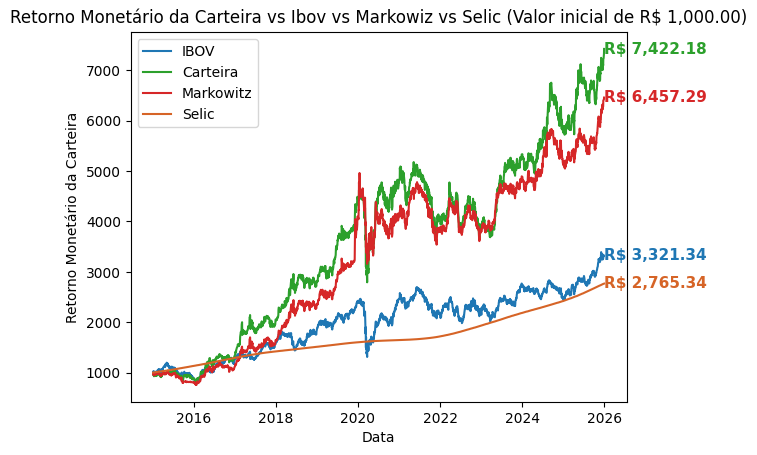

In [124]:
#datas_lista = list(results_dict.keys())
datas_lista = list(precos_carteira.keys())

start_bove = datas_lista[0]

end_bove = datas_lista[-1]

selic = get_selic_multiplos_periodos(start_bove, end_bove)

selic_acumulada =  ((selic/100 + 1).cumprod())*valor_investido


ibov = yf.download("^BVSP", start=start_bove, end=end_bove)["Close"]

ibov_retornos = (ibov.pct_change()+1).cumprod()*valor_investido

retorno_acumulado_monetario = pd.concat([selic_acumulada, ibov_retornos], axis=1).rename(columns={"selic": "Selic", "^BVSP": "IBOV"})

carteira_marcowitz = carteira_marcowitz[~carteira_marcowitz.index.duplicated(keep='last')]

carteira = carteira[~carteira.index.duplicated(keep='last')]

retorno_acumulado_monetario['Markowitz'] = carteira_marcowitz

retorno_acumulado_monetario['Carteira'] = carteira

metricas_carteiras = compute_metrics(retorno_acumulado_monetario)

metricas_carteiras.style.set_caption("Métricas das Carteiras").background_gradient(cmap="Blues")


cores = {'IBOV': '#1f77b4', 'Carteira': '#2ca02c', 'Markowitz': '#d62728', 'Selic': "#d66427"}

retorno_acumulado_monetario = retorno_acumulado_monetario.dropna()

for nome in ['IBOV', 
             'Carteira', 
             'Markowitz', 
             'Selic']:
    plt.plot(
            retorno_acumulado_monetario.index,
            retorno_acumulado_monetario[nome],
                label=nome,
                color=cores[nome]
            )
    ultimo_x = retorno_acumulado_monetario[nome].index[-1]
    ultimo_y = retorno_acumulado_monetario[nome].iloc[-1]
    plt.text(
                ultimo_x, ultimo_y,
                f'R$ {ultimo_y:,.2f}',
                color=cores[nome],
                fontsize=11,
                va='center',
                fontweight='bold'
            )

plt.legend()
plt.xlabel("Data")
plt.ylabel("Retorno Monetário da Carteira")
plt.title(f"Retorno Monetário da Carteira vs Ibov vs Markowiz vs Selic (Valor inicial de R$ {valor_investido:,.2f})")

os.makedirs(save_path, exist_ok=True)

metrics_file = os.path.join(save_path, "metricas_carteiras_historico.csv")

metricas_carteiras.to_csv(metrics_file)

logger.info(f"✅ Métricas salvas em: {metrics_file}")

image_path = "../../image"

grafico_file = os.path.join(image_path, f"grafico_retornos_carteira_historico.png")

plt.savefig(grafico_file, dpi=300, bbox_inches='tight')

logger.info(f"✅ Gráfico salvo em: {grafico_file}")

logger.info(f"Avaliação concluida com sucesso!")

In [125]:
metricas_carteiras

,retorno_medio_anual,volatilidade_anual,cagr,max_drawdown,avg_drawdown,calmar,sortino
Selic,0.092936,0.002409,0.096935,0.000000,0.000000,NaN,NaN
IBOV,0.140260,0.233178,0.117582,-0.468158,-0.039887,0.251159,NaN
Markowitz,0.200273,0.220728,0.186127,-0.363360,-0.043037,0.512238,NaN
Carteira,0.217169,0.234632,0.201913,-0.409068,-0.052710,0.493595,NaN


In [126]:
retorno_acumulado_monetario

,Selic,IBOV,Markowitz,Carteira
Date,,,,
2015-01-05,1000.874971,979.489611,990.315978,984.427175
2015-01-06,1001.312744,989.466524,971.333826,962.737417
2015-01-07,1001.750708,1019.603397,959.935329,950.460828
2015-01-08,1002.188864,1029.497856,973.615651,964.283531
2015-01-09,1002.627211,1006.761214,966.547382,955.889785
...,...,...,...,...
2025-12-22,2757.729301,3259.853232,6279.963139,7094.457740
2025-12-23,2759.249665,3307.552770,6399.031691,7215.755389
2025-12-26,2762.292908,3316.643305,6409.061249,7239.255276


In [14]:
from utils import annualized_mean_return, daily_returns_carteira, daily_returns

In [15]:
compute_metrics(retorno_acumulado_monetario)

,retorno_medio_anual,volatilidade_anual,cagr,max_drawdown,avg_drawdown,calmar,sortino
Selic,0.108161,0.025156,0.096938,0.000000,0.000000,NaN,NaN
IBOV,0.163916,0.252679,0.117582,-0.406688,-0.038102,0.289122,NaN
Markowitz,0.228462,0.208293,0.194010,-0.260820,-0.043879,0.743848,NaN
Carteira,0.254338,0.228375,0.216207,-0.324498,-0.048656,0.666283,NaN


In [3]:
import pandas as pd
url = "https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv"
dre = pd.read_csv(url, index_col=0, parse_dates=True)

C:\Users\jefer\AppData\Local\Temp\ipykernel_24472\1922060118.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dre = pd.read_csv(url, index_col=0, parse_dates=True)


In [5]:
dre.to_markdown()

'|     | Empresa      | Segmento de Listagem              | Setor                           | Segmento                                 | tic    |\n|----:|:-------------|:----------------------------------|:--------------------------------|:-----------------------------------------|:-------|\n|   0 | ALLIAR       | Novo Mercado                      | Saúde                           | Serv.Méd.Hospit..Análises e Diagnósticos | AALR3  |\n|   1 | AMBEV S/A    | Tradicional - BOVESPA             | Consumo não Cíclico             | Cervejas e Refrigerantes                 | ABEV3  |\n|   2 | AFLUENTE T   | Tradicional - BOVESPA             | Utilidade Pública               | Energia Elétrica                         | AFLT3  |\n|   3 | BRASILAGRO   | Novo Mercado                      | Consumo não Cíclico             | Agricultura                              | AGRO3  |\n|   4 | AGROGALAXY   | Novo Mercado                      | Consumo não Cíclico             | Agricultura                   